In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
df = pd.read_csv('turboaz.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (1328, 16)

First 5 rows:
     Sheher     Marka  Model  Buraxilish ili Ban novu    Reng  \
0  Sumqayıt  Mercedes  C 200            1999    Sedan    Qara   
1      Bakı  Mercedes  C 180            2014    Sedan    Qara   
2  Sumqayıt  Mercedes  C 240            2002    Sedan    Qara   
3    Şirvan  Mercedes  C 180            1998    Sedan     Göy   
4  Sumqayıt  Mercedes  C 220            2000    Sedan  Gümüşü   

  Muherrikin hecmi Muherrikin gucu Yanacaq novu      Yurush Suretler qutusu  \
0            2.0 L        175 a.g.       Benzin  366 000 km         Avtomat   
1            1.6 L        167 a.g.       Benzin  102 000 km         Avtomat   
2            2.6 L        177 a.g.       Benzin  469 700 km         Avtomat   
3            1.8 L        125 a.g.       Benzin  556 680 km         Avtomat   
4            2.2 L        150 a.g.        Dizel  300 000 km         Avtomat   

  Oturucu  Yeni     Qiymet                                         Extra Info  \
0    Arxa  X

In [2]:
def clean_mileage(mileage_value):
    if pd.isna(mileage_value):
        return None
    mileage_str = str(mileage_value)
    cleaned = mileage_str.replace('km', '').replace(' ', '')
    try:
        return float(cleaned)
    except ValueError:
        return None

def clean_price(price_value):
    if pd.isna(price_value):
        return None
    price_str = str(price_value)
    if '$' in price_str:
        dollar_amount = price_str.replace('$', '').replace(' ', '')
        try:
            dollar_value = float(dollar_amount)
            azn_value = dollar_value * 1.7
            return azn_value
        except ValueError:
            return None
    elif 'AZN' in price_str:
        azn_amount = price_str.replace('AZN', '').replace(' ', '')
        try:
            return float(azn_amount)
        except ValueError:
            return None
    else:
        try:
            return float(price_str.replace(' ', ''))
        except ValueError:
            return None

print("Cleaning is successful!")

Cleaning is successful!


In [3]:
X1 = df['Yurush'].apply(clean_mileage)
X2 = df['Buraxilish ili'].copy()
Y = df['Qiymet'].apply(clean_price)

mask = X1.notna() & X2.notna() & Y.notna()
X1_clean = X1[mask]
X2_clean = X2[mask]
Y_clean = Y[mask]

print("=== CLEANED DATA ===")
print(f"Original data size: {len(df)}")
print(f"Clean data size: {len(X1_clean)}")
print(f"Removed {len(df) - len(X1_clean)} rows with missing data")

print("\nX1 (Mileage - cleaned):")
print(X1_clean.head())

print("\nX2 (Year):")
print(X2_clean.head())

print("\nY (Price in AZN - cleaned):")
print(Y_clean.head())

print("\n=== SUMMARY STATISTICS ===")
print(f"Mileage range: {X1_clean.min():,.0f} - {X1_clean.max():,.0f} km")
print(f"Year range: {X2_clean.min()} - {X2_clean.max()}")
print(f"Price range: {Y_clean.min():,.0f} - {Y_clean.max():,.0f} AZN")

=== CLEANED DATA ===
Original data size: 1328
Clean data size: 1328
Removed 0 rows with missing data

X1 (Mileage - cleaned):
0    366000.0
1    102000.0
2    469700.0
3    556680.0
4    300000.0
Name: Yurush, dtype: float64

X2 (Year):
0    1999
1    2014
2    2002
3    1998
4    2000
Name: Buraxilish ili, dtype: int64

Y (Price in AZN - cleaned):
0    12500.0
1    53550.0
2    11700.0
3     9700.0
4    12700.0
Name: Qiymet, dtype: float64

=== SUMMARY STATISTICS ===
Mileage range: 0 - 876,000 km
Year range: 1989 - 2018
Price range: 1,130 - 99,500 AZN


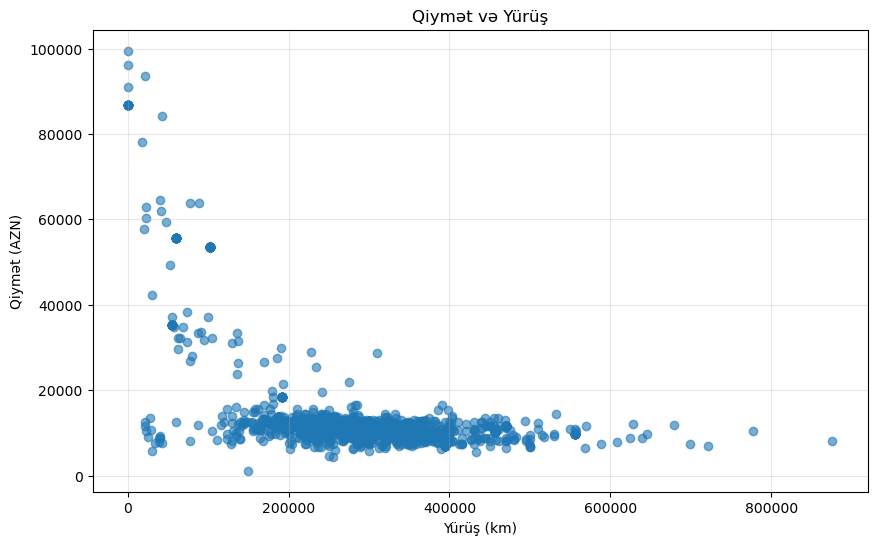

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X1_clean, Y_clean, alpha=0.6)
plt.xlabel('Yürüş (km)')
plt.ylabel('Qiymət (AZN)')
plt.title('Qiymət və Yürüş')
plt.grid(True, alpha=0.3)
plt.show()

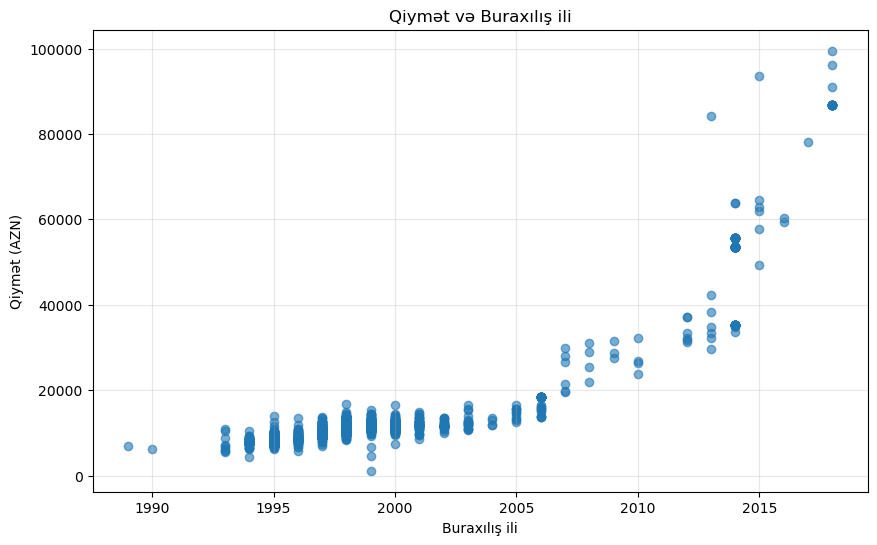

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(X2_clean, Y_clean, alpha=0.6)
plt.xlabel('Buraxılış ili')
plt.ylabel('Qiymət (AZN)')
plt.title('Qiymət və Buraxılış ili')
plt.grid(True, alpha=0.3)
plt.show()

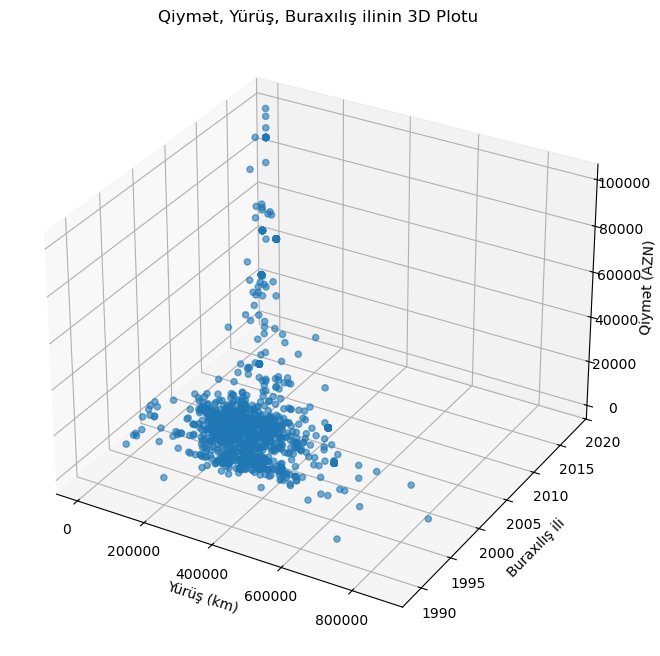

In [6]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1_clean, X2_clean, Y_clean, alpha=0.6)
ax.set_xlabel('Yürüş (km)')
ax.set_ylabel('Buraxılış ili')
ax.set_zlabel('Qiymət (AZN)')
ax.set_title('Qiymət, Yürüş, Buraxılış ilinin 3D Plotu')
plt.show()

In [7]:
def cost_function(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost

def hypothesis(X, theta):
    return X.dot(theta)

m = len(X1_clean)
X = np.column_stack([np.ones(m), X1_clean, X2_clean])
y = Y_clean.values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 rows of X:")
print(X[:5])

theta_test = np.array([0, 0, 0])
cost_test = cost_function(X, y, theta_test)
print(f"\nInitial cost with theta=[0,0,0]: {cost_test:,.0f}")

X shape: (1328, 3)
y shape: (1328,)
First 5 rows of X:
[[1.0000e+00 3.6600e+05 1.9990e+03]
 [1.0000e+00 1.0200e+05 2.0140e+03]
 [1.0000e+00 4.6970e+05 2.0020e+03]
 [1.0000e+00 5.5668e+05 1.9980e+03]
 [1.0000e+00 3.0000e+05 2.0000e+03]]

Initial cost with theta=[0,0,0]: 207,350,412


In [8]:
def normalize_features(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])
    
    for i in range(1, X.shape[1]):
        mu[i] = np.mean(X[:, i])
        sigma[i] = np.std(X[:, i])
        X_norm[:, i] = (X[:, i] - mu[i]) / sigma[i]
    
    return X_norm, mu, sigma

X_norm, mu, sigma = normalize_features(X)

print("Original X first 5 rows:")
print(X[:5])
print("\nNormalized X first 5 rows:")
print(X_norm[:5])
print(f"\nMu (means): {mu}")
print(f"Sigma (std): {sigma}")

cost_normalized = cost_function(X_norm, y, theta_test)
print(f"\nCost with normalized data: {cost_normalized:,.0f}")

Original X first 5 rows:
[[1.0000e+00 3.6600e+05 1.9990e+03]
 [1.0000e+00 1.0200e+05 2.0140e+03]
 [1.0000e+00 4.6970e+05 2.0020e+03]
 [1.0000e+00 5.5668e+05 1.9980e+03]
 [1.0000e+00 3.0000e+05 2.0000e+03]]

Normalized X first 5 rows:
[[ 1.          0.71615726 -0.16254492]
 [ 1.         -1.47336614  2.65301575]
 [ 1.          1.57620869  0.40056722]
 [ 1.          2.29759029 -0.35024896]
 [ 1.          0.16877641  0.02515913]]

Mu (means): [     0.         279649.92168675   1999.86596386]
Sigma (std): [0.00000000e+00 1.20574185e+05 5.32753571e+00]

Cost with normalized data: 207,350,412


In [9]:
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []
    
    for i in range(iterations):
        predictions = hypothesis(X, theta)
        errors = predictions - y
        
        theta = theta - (alpha/m) * X.T.dot(errors)
        
        cost = cost_function(X, y, theta)
        cost_history.append(cost)
        
        # Print progress every 1000 iterations
        if i % 1000 == 0:
            print(f"Iteration {i}: Cost = {cost:,.0f}")
    
    return theta, cost_history

theta_initial = np.array([0.0, 0.0, 0.0])
alpha = 0.001
iterations = 10000

print("Starting gradient descent...")
theta_final, cost_history = gradient_descent(X_norm, y, theta_initial, alpha, iterations)

print(f"\nFinal theta: {theta_final}")
print(f"Final cost: {cost_history[-1]:,.0f}")
print(f"Cost reduction: {cost_history[0]:,.0f} -> {cost_history[-1]:,.0f}")
print(f"Improvement: {((cost_history[0]-cost_history[-1])/cost_history[0]*100):.1f}%")

Starting gradient descent...
Iteration 0: Cost = 206,916,688
Iteration 1000: Cost = 42,480,422
Iteration 2000: Cost = 23,927,067
Iteration 3000: Cost = 20,890,313
Iteration 4000: Cost = 20,165,983
Iteration 5000: Cost = 19,931,277
Iteration 6000: Cost = 19,841,445
Iteration 7000: Cost = 19,804,684
Iteration 8000: Cost = 19,789,288
Iteration 9000: Cost = 19,782,790

Final theta: [15115.77165724 -1342.29314417 11268.82440011]
Final cost: 19,780,043
Cost reduction: 206,916,688 -> 19,780,043
Improvement: 90.4%


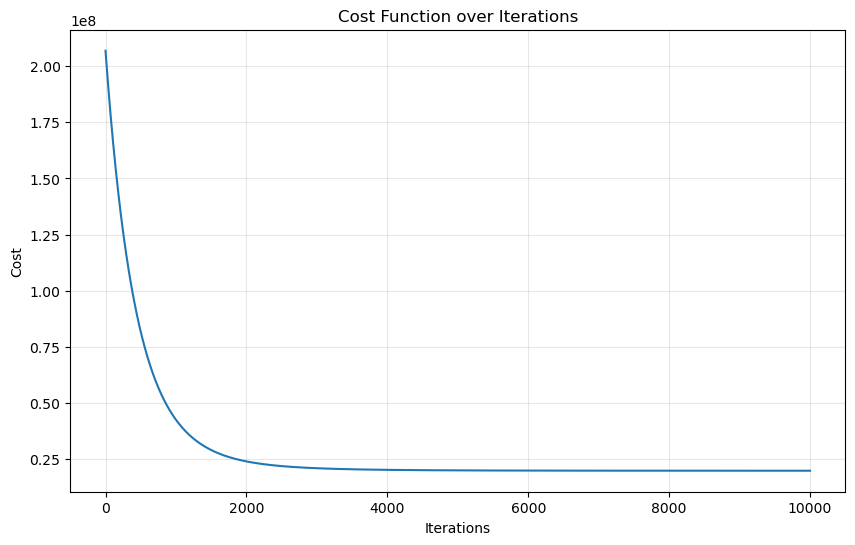

Cost reduction: 206,916,688 -> 19,780,043
Improvement: 90.4%


In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function over Iterations')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Cost reduction: {cost_history[0]:,.0f} -> {cost_history[-1]:,.0f}")
print(f"Improvement: {((cost_history[0]-cost_history[-1])/cost_history[0]*100):.1f}%")

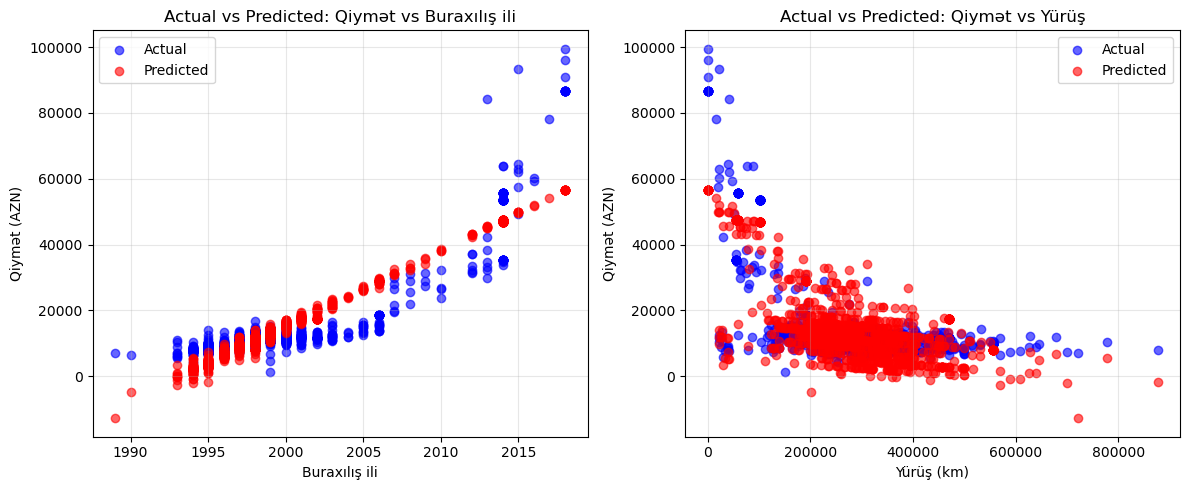

In [11]:
predictions = hypothesis(X_norm, theta_final)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X2_clean, Y_clean, alpha=0.6, label='Actual', color='blue')
plt.scatter(X2_clean, predictions, alpha=0.6, label='Predicted', color='red')
plt.xlabel('Buraxılış ili')
plt.ylabel('Qiymət (AZN)')
plt.title('Actual vs Predicted: Qiymət vs Buraxılış ili')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X1_clean, Y_clean, alpha=0.6, label='Actual', color='blue')
plt.scatter(X1_clean, predictions, alpha=0.6, label='Predicted', color='red')
plt.xlabel('Yürüş (km)')
plt.ylabel('Qiymət (AZN)')
plt.title('Actual vs Predicted: Qiymət vs Yürüş')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

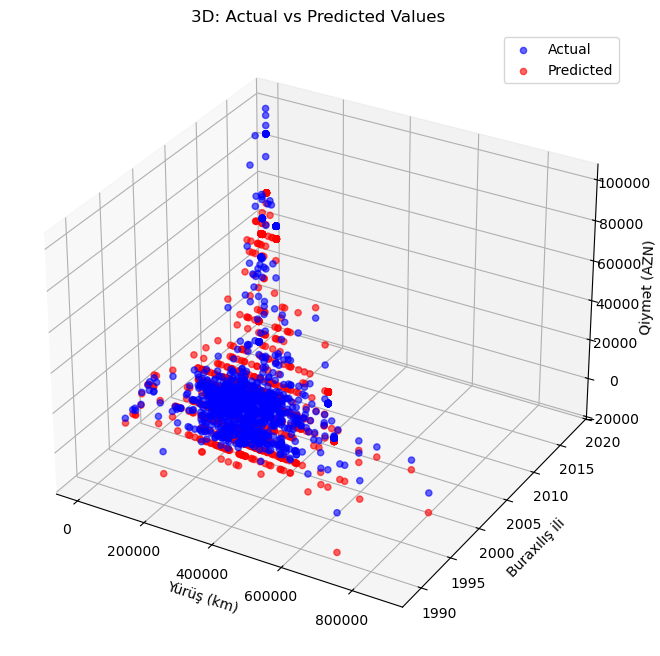

In [12]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1_clean, X2_clean, Y_clean, alpha=0.6, color='blue', label='Actual')

ax.scatter(X1_clean, X2_clean, predictions, alpha=0.6, color='red', label='Predicted')

ax.set_xlabel('Yürüş (km)')
ax.set_ylabel('Buraxılış ili')
ax.set_zlabel('Qiymət (AZN)')
ax.set_title('3D: Actual vs Predicted Values')
ax.legend()
plt.show()

In [13]:
print("=== TESTING NEW CARS ===")

# Car 1
car1_mileage = 240000
car1_year = 2000
car1_actual_price = 11500

# Car 2  
car2_mileage = 415558
car2_year = 1996
car2_actual_price = 8800

car1_features = np.array([1, car1_mileage, car1_year])
car2_features = np.array([1, car2_mileage, car2_year])

car1_norm = car1_features.copy()
car1_norm[1] = (car1_features[1] - mu[1]) / sigma[1]  # Normalize mileage
car1_norm[2] = (car1_features[2] - mu[2]) / sigma[2]  # Normalize year

car2_norm = car2_features.copy()
car2_norm[1] = (car2_features[1] - mu[1]) / sigma[1]  # Normalize mileage
car2_norm[2] = (car2_features[2] - mu[2]) / sigma[2]  # Normalize year

car1_predicted = car1_norm.dot(theta_final)
car2_predicted = car2_norm.dot(theta_final)

print(f"Car 1:")
print(f"  Features: {car1_mileage} km, {car1_year} year")
print(f"  Actual price: {car1_actual_price:,.0f} AZN")
print(f"  Predicted price: {car1_predicted:,.0f} AZN")
print(f"  Error: {abs(car1_actual_price - car1_predicted):,.0f} AZN")

print(f"\nCar 2:")
print(f"  Features: {car2_mileage} km, {car2_year} year")
print(f"  Actual price: {car2_actual_price:,.0f} AZN")
print(f"  Predicted price: {car2_predicted:,.0f} AZN")
print(f"  Error: {abs(car2_actual_price - car2_predicted):,.0f} AZN")

=== TESTING NEW CARS ===
Car 1:
  Features: 240000 km, 2000 year
  Actual price: 11,500 AZN
  Predicted price: 15,116 AZN
  Error: 3,616 AZN

Car 2:
  Features: 415558 km, 1996 year
  Actual price: 8,800 AZN
  Predicted price: 13,773 AZN
  Error: 4,973 AZN


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [29]:

X_features = np.column_stack([X1_clean, X2_clean])
y_target = Y_clean  

print(f"Feature matrix shape: {X_features.shape}")
print(f"Target vector shape: {y_target.shape}")
print(f"First 5 samples of features:")
print(X_features[:5])
print(f"First 5 samples of target:")
print(y_target[:5])

Feature matrix shape: (1328, 2)
Target vector shape: (1328,)
First 5 samples of features:
[[366000.   1999.]
 [102000.   2014.]
 [469700.   2002.]
 [556680.   1998.]
 [300000.   2000.]]
First 5 samples of target:
0    12500.0
1    53550.0
2    11700.0
3     9700.0
4    12700.0
Name: Qiymet, dtype: float64


In [30]:
print("Normalizing features for consistency with gradient descent...")

X1_mean = np.mean(X_features[:, 0])  
X1_std = np.std(X_features[:, 0])   
X2_mean = np.mean(X_features[:, 1]) 
X2_std = np.std(X_features[:, 1])   

print(f"Normalization parameters:")
print(f"Mileage: mean={X1_mean:.2f}, std={X1_std:.2f}")
print(f"Year: mean={X2_mean:.2f}, std={X2_std:.2f}")

# Apply normalization
X_features_normalized = X_features.copy()
X_features_normalized[:, 0] = (X_features[:, 0] - X1_mean) / X1_std 
X_features_normalized[:, 1] = (X_features[:, 1] - X2_mean) / X2_std

print(f"\nFirst 5 samples after normalization:")
print(X_features_normalized[:5])

model = LinearRegression()
model.fit(X_features_normalized, y_target)

print("\nScikit-learn Linear Regression Parameters (with normalized features):")
print(f"Intercept (θ0): {model.intercept_:.6f}")
print(f"Coefficients:")
print(f"  θ1 (mileage coefficient): {model.coef_[0]:.6f}")
print(f"  θ2 (year coefficient): {model.coef_[1]:.6f}")

# Make predictions on the training data
predictions_sklearn = model.predict(X_features_normalized)

print(f"\nFirst 5 predictions: {predictions_sklearn[:5]}")
print(f"First 5 actual values: {y_target[:5]}")

normalization_params = {
    'X1_mean': X1_mean, 'X1_std': X1_std,
    'X2_mean': X2_mean, 'X2_std': X2_std
}

Normalizing features for consistency with gradient descent...
Normalization parameters:
Mileage: mean=279649.92, std=120574.19
Year: mean=1999.87, std=5.33

First 5 samples after normalization:
[[ 0.71615726 -0.16254492]
 [-1.47336614  2.65301575]
 [ 1.57620869  0.40056722]
 [ 2.29759029 -0.35024896]
 [ 0.16877641  0.02515913]]

Scikit-learn Linear Regression Parameters (with normalized features):
Intercept (θ0): 15116.454518
Coefficients:
  θ1 (mileage coefficient): -1273.701446
  θ2 (year coefficient): 11337.417980

First 5 predictions: [12361.44430291 47071.43156553 17650.2331888   8219.09155007
 15186.72329161]
First 5 actual values: 0    12500.0
1    53550.0
2    11700.0
3     9700.0
4    12700.0
Name: Qiymet, dtype: float64


In [31]:
mse = mean_squared_error(y_target, predictions_sklearn)
r2 = r2_score(y_target, predictions_sklearn)

print(f"Model Performance:")
print(f"Mean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.6f}")

cost_sklearn = mse / 2  # MSE/2 to match your cost function definition
print(f"Cost Function Value: {cost_sklearn:.6f}")

mae = np.mean(np.abs(y_target - predictions_sklearn))
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae:.6f}")
print(f"Root Mean Squared Error: {rmse:.6f}")

Model Performance:
Mean Squared Error: 39556044.579861
R² Score: 0.787554
Cost Function Value: 19778022.289931
Mean Absolute Error: 4213.423763
Root Mean Squared Error: 6289.359632


In [32]:
car1_mileage = 240000
car1_year = 2000
car1_actual_price = 11500

car2_mileage = 415558
car2_year = 1996
car2_actual_price = 8800

print(f"Testing cars:")
print(f"Car 1: {car1_mileage} km, {car1_year} year, actual price: {car1_actual_price} AZN")
print(f"Car 2: {car2_mileage} km, {car2_year} year, actual price: {car2_actual_price} AZN")

if 'X1' in globals() and 'X2' in globals():
    mu_mileage_orig = X1.mean()
    sigma_mileage_orig = X1.std()
    mu_year_orig = X2.mean() 
    sigma_year_orig = X2.std()
    print("Using original data normalization parameters")
elif 'mu' in globals() and 'sigma' in globals():
    mu_mileage_orig = mu[1] if len(mu) > 1 else mu
    sigma_mileage_orig = sigma[1] if len(sigma) > 1 else sigma
    mu_year_orig = mu[2] if len(mu) > 2 else mu
    sigma_year_orig = sigma[2] if len(sigma) > 2 else sigma
    print("Using stored mu and sigma")
else:
    mu_mileage_orig = np.mean(X_features[:, 0])
    sigma_mileage_orig = np.std(X_features[:, 0])
    mu_year_orig = np.mean(X_features[:, 1])
    sigma_year_orig = np.std(X_features[:, 1])
    print("Calculating normalization parameters from current data")

print(f"Normalization parameters:")
print(f"Mileage: mean={mu_mileage_orig:.2f}, std={sigma_mileage_orig:.2f}")
print(f"Year: mean={mu_year_orig:.2f}, std={sigma_year_orig:.2f}")

car1_mileage_norm = (car1_mileage - mu_mileage_orig) / sigma_mileage_orig
car1_year_norm = (car1_year - mu_year_orig) / sigma_year_orig

car2_mileage_norm = (car2_mileage - mu_mileage_orig) / sigma_mileage_orig
car2_year_norm = (car2_year - mu_year_orig) / sigma_year_orig

print(f"\nNormalized features:")
print(f"Car 1: mileage_norm={car1_mileage_norm:.4f}, year_norm={car1_year_norm:.4f}")
print(f"Car 2: mileage_norm={car2_mileage_norm:.4f}, year_norm={car2_year_norm:.4f}")

car1_features = np.array([[car1_mileage_norm, car1_year_norm]])
car2_features = np.array([[car2_mileage_norm, car2_year_norm]])

car1_predicted = model.predict(car1_features)[0]
car2_predicted = model.predict(car2_features)[0]

print(f"\nPrediction Results:")
print("Car 1:")
print(f"  Features: {car1_mileage} km, {car1_year} year")
print(f"  Actual price: {car1_actual_price:.2f} AZN")
print(f"  Predicted price: {car1_predicted:.2f} AZN")
print(f"  Error: {abs(car1_actual_price - car1_predicted):.2f} AZN")
print(f"  Relative error: {abs(car1_actual_price - car1_predicted)/car1_actual_price*100:.2f}%")

print("\nCar 2:")
print(f"  Features: {car2_mileage} km, {car2_year} year")
print(f"  Actual price: {car2_actual_price:.2f} AZN")
print(f"  Predicted price: {car2_predicted:.2f} AZN")
print(f"  Error: {abs(car2_actual_price - car2_predicted):.2f} AZN")
print(f"  Relative error: {abs(car2_actual_price - car2_predicted)/car2_actual_price*100:.2f}%")

Testing cars:
Car 1: 240000 km, 2000 year, actual price: 11500 AZN
Car 2: 415558 km, 1996 year, actual price: 8800 AZN
Using original data normalization parameters
Normalization parameters:
Mileage: mean=279649.92, std=120619.61
Year: mean=1999.87, std=5.33

Normalized features:
Car 1: mileage_norm=-0.3287, year_norm=0.0251
Car 2: mileage_norm=1.1267, year_norm=-0.7254

Prediction Results:
Car 1:
  Features: 240000 km, 2000 year
  Actual price: 11500.00 AZN
  Predicted price: 15820.28 AZN
  Error: 4320.28 AZN
  Relative error: 37.57%

Car 2:
  Features: 415558 km, 1996 year
  Actual price: 8800.00 AZN
  Predicted price: 5457.33 AZN
  Error: 3342.67 AZN
  Relative error: 37.98%


In [34]:

print("Normalizing features for consistency with gradient descent...")

X1_mean = np.mean(X_features[:, 0])
X1_std = np.std(X_features[:, 0])
X2_mean = np.mean(X_features[:, 1])
X2_std = np.std(X_features[:, 1])

print(f"Normalization parameters:")
print(f"Mileage: mean={X1_mean:.2f}, std={X1_std:.2f}")
print(f"Year: mean={X2_mean:.2f}, std={X2_std:.2f}")

X_features_normalized = X_features.copy()
X_features_normalized[:, 0] = (X_features[:, 0] - X1_mean) / X1_std
X_features_normalized[:, 1] = (X_features[:, 1] - X2_mean) / X2_std

print(f"\nFirst 5 samples after normalization:")
print(X_features_normalized[:5])

model = LinearRegression()
model.fit(X_features_normalized, y_target)

print("\nScikit-learn Linear Regression Parameters (with normalized features):")
print(f"Intercept (θ0): {model.intercept_:.6f}")
print(f"Coefficients:")
print(f"  θ1 (mileage coefficient): {model.coef_[0]:.6f}")
print(f"  θ2 (year coefficient): {model.coef_[1]:.6f}")

predictions_sklearn = model.predict(X_features_normalized)

print(f"\nFirst 5 predictions: {predictions_sklearn[:5]}")
print(f"First 5 actual values: {y_target[:5]}")

normalization_params = {
    'X1_mean': X1_mean, 'X1_std': X1_std,
    'X2_mean': X2_mean, 'X2_std': X2_std
}

Normalizing features for consistency with gradient descent...
Normalization parameters:
Mileage: mean=279649.92, std=120574.19
Year: mean=1999.87, std=5.33

First 5 samples after normalization:
[[ 0.71615726 -0.16254492]
 [-1.47336614  2.65301575]
 [ 1.57620869  0.40056722]
 [ 2.29759029 -0.35024896]
 [ 0.16877641  0.02515913]]

Scikit-learn Linear Regression Parameters (with normalized features):
Intercept (θ0): 15116.454518
Coefficients:
  θ1 (mileage coefficient): -1273.701446
  θ2 (year coefficient): 11337.417980

First 5 predictions: [12361.44430291 47071.43156553 17650.2331888   8219.09155007
 15186.72329161]
First 5 actual values: 0    12500.0
1    53550.0
2    11700.0
3     9700.0
4    12700.0
Name: Qiymet, dtype: float64


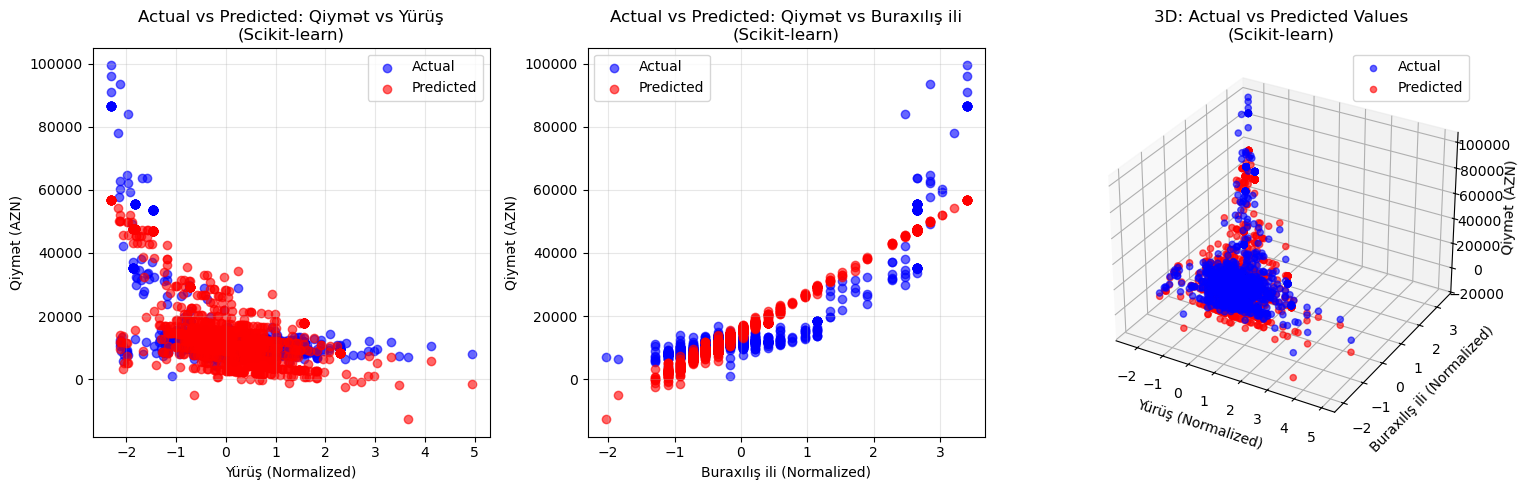

Generated 3 plots:
1. Qiymət vs Yürüş (Mileage) - Actual vs Predicted
2. Qiymət vs Buraxılış ili (Year) - Actual vs Predicted
3. 3D plot showing all three variables


In [35]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_features_normalized[:, 0], y_target, alpha=0.6, label='Actual', color='blue')
plt.scatter(X_features_normalized[:, 0], predictions_sklearn, alpha=0.6, label='Predicted', color='red')
plt.xlabel('Yürüş (Normalized)')
plt.ylabel('Qiymət (AZN)')
plt.title('Actual vs Predicted: Qiymət vs Yürüş\n(Scikit-learn)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted (Year relationship)
plt.subplot(1, 3, 2)
plt.scatter(X_features_normalized[:, 1], y_target, alpha=0.6, label='Actual', color='blue')
plt.scatter(X_features_normalized[:, 1], predictions_sklearn, alpha=0.6, label='Predicted', color='red')
plt.xlabel('Buraxılış ili (Normalized)')
plt.ylabel('Qiymət (AZN)')
plt.title('Actual vs Predicted: Qiymət vs Buraxılış ili\n(Scikit-learn)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: 3D visualization
ax = plt.subplot(1, 3, 3, projection='3d')
ax.scatter(X_features_normalized[:, 0], X_features_normalized[:, 1], y_target, alpha=0.6, label='Actual', color='blue')
ax.scatter(X_features_normalized[:, 0], X_features_normalized[:, 1], predictions_sklearn, alpha=0.6, label='Predicted', color='red')
ax.set_xlabel('Yürüş (Normalized)')
ax.set_ylabel('Buraxılış ili (Normalized)')
ax.set_zlabel('Qiymət (AZN)')
ax.set_title('3D: Actual vs Predicted Values\n(Scikit-learn)')
ax.legend()

plt.tight_layout()
plt.show()

print("Generated 3 plots:")
print("1. Qiymət vs Yürüş (Mileage) - Actual vs Predicted")
print("2. Qiymət vs Buraxılış ili (Year) - Actual vs Predicted") 
print("3. 3D plot showing all three variables")

In [36]:
print("Parameter Comparison:")
if 'theta_final' in globals():
    print(f"Your Gradient Descent - θ0: {theta_final[0]:.6f}, θ1: {theta_final[1]:.6f}, θ2: {theta_final[2]:.6f}")
    
    theta_diff_0 = abs(theta_final[0] - model.intercept_)
    theta_diff_1 = abs(theta_final[1] - model.coef_[0])
    theta_diff_2 = abs(theta_final[2] - model.coef_[1])
    
    print(f"Parameter differences:")
    print(f"  |θ0_gradient - θ0_sklearn| = {theta_diff_0:.6f}")
    print(f"  |θ1_gradient - θ1_sklearn| = {theta_diff_1:.6f}")
    print(f"  |θ2_gradient - θ2_sklearn| = {theta_diff_2:.6f}")
else:
    print("Gradient descent results not found. Make sure you have 'theta_final' variable from Part 3.")

print(f"Scikit-learn          - θ0: {model.intercept_:.6f}, θ1: {model.coef_[0]:.6f}, θ2: {model.coef_[1]:.6f}")

print(f"\nCost Function Comparison:")
if 'cost_history' in globals():
    gradient_final_cost = cost_history[-1]
    print(f"Your gradient descent final cost: {gradient_final_cost:.6f}")
    print(f"Scikit-learn cost:               {cost_sklearn:.6f}")
    print(f"Cost difference: {abs(gradient_final_cost - cost_sklearn):.6f}")
    
    if abs(gradient_final_cost - cost_sklearn) < 0.001:
        print("✅ Both methods converged to very similar solutions!")
    else:
        print("⚠️  Different cost values - check implementation or convergence")
else:
    print("Gradient descent cost history not found. Make sure you have 'cost_history' variable from Part 3.")
    print(f"Scikit-learn cost: {cost_sklearn:.6f}")

if 'theta_final' in globals() and 'cost_history' in globals():
    print(f"\n{'Method':<20} {'θ0':<12} {'θ1':<12} {'θ2':<12} {'Final Cost':<12}")
    print("="*68)
    print(f"{'Gradient Descent':<20} {theta_final[0]:<12.6f} {theta_final[1]:<12.6f} {theta_final[2]:<12.6f} {cost_history[-1]:<12.6f}")
    print(f"{'Scikit-learn':<20} {model.intercept_:<12.6f} {model.coef_[0]:<12.6f} {model.coef_[1]:<12.6f} {cost_sklearn:<12.6f}")

Parameter Comparison:
Your Gradient Descent - θ0: 15115.771657, θ1: -1342.293144, θ2: 11268.824400
Parameter differences:
  |θ0_gradient - θ0_sklearn| = 0.682861
  |θ1_gradient - θ1_sklearn| = 68.591698
  |θ2_gradient - θ2_sklearn| = 68.593580
Scikit-learn          - θ0: 15116.454518, θ1: -1273.701446, θ2: 11337.417980

Cost Function Comparison:
Your gradient descent final cost: 19780043.034288
Scikit-learn cost:               19778022.289931
Cost difference: 2020.744357
⚠️  Different cost values - check implementation or convergence

Method               θ0           θ1           θ2           Final Cost  
Gradient Descent     15115.771657 -1342.293144 11268.824400 19780043.034288
Scikit-learn         15116.454518 -1273.701446 11337.417980 19778022.289931


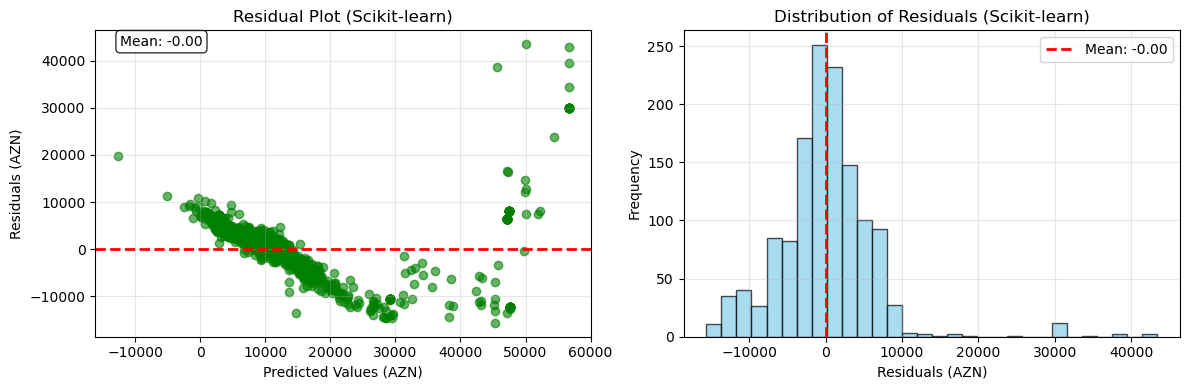

Residual Statistics:
Mean of residuals: -0.000000
Standard deviation of residuals: 6289.359632
Min residual: -15610.62 AZN
Max residual: 43455.40 AZN
Median absolute residual: 2969.69 AZN

Shapiro-Wilk test for normality:
Statistic: 0.8673, p-value: 0.000000
⚠️  Residuals may not be normally distributed


In [37]:
residuals = y_target - predictions_sklearn

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(predictions_sklearn, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values (AZN)')
plt.ylabel('Residuals (AZN)')
plt.title('Residual Plot (Scikit-learn)')
plt.grid(True, alpha=0.3)

plt.text(0.05, 0.95, f'Mean: {np.mean(residuals):.2f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Residuals (AZN)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Scikit-learn)')
plt.grid(True, alpha=0.3)

plt.axvline(np.mean(residuals), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(residuals):.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"Mean of residuals: {np.mean(residuals):.6f}")
print(f"Standard deviation of residuals: {np.std(residuals):.6f}")
print(f"Min residual: {np.min(residuals):.2f} AZN")
print(f"Max residual: {np.max(residuals):.2f} AZN")
print(f"Median absolute residual: {np.median(np.abs(residuals)):.2f} AZN")

try:
    from scipy import stats
    shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
    print(f"\nShapiro-Wilk test for normality:")
    print(f"Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.6f}")
    if shapiro_p > 0.05:
        print("✅ Residuals appear to be normally distributed (good!)")
    else:
        print("⚠️  Residuals may not be normally distributed")
except ImportError:
    print("\nScipy not available for normality test")

In [38]:
def normal_equation_linear_regression(X, y):
    """
    θ = (X^T * X)^(-1) * X^T * y
    """
    X_with_bias = np.column_stack([np.ones(X.shape[0]), X])
    X_transpose = X_with_bias.T
    theta = np.linalg.inv(X_transpose @ X_with_bias) @ X_transpose @ y
    return theta

def predict_normal_equation(X, theta):
    """
    Make predictions using normal equation parameters
    """
    X_with_bias = np.column_stack([np.ones(X.shape[0]), X])
    return X_with_bias @ theta

print("Normal equation functions defined:")
print("1. normal_equation_linear_regression(X, y)")
print("2. predict_normal_equation(X, theta)")

Normal equation functions defined:
1. normal_equation_linear_regression(X, y)
2. predict_normal_equation(X, theta)


In [39]:
X_features_part5 = np.column_stack([X_features[:, 0], X_features[:, 1]])

if 'X1' in globals() and 'X2' in globals():
    mu_mileage = X1.mean()
    sigma_mileage = X1.std()
    mu_year = X2.mean()
    sigma_year = X2.std()
    print("Using original normalization parameters from gradient descent")
else:
    mu_mileage = np.mean(X_features_part5[:, 0])
    sigma_mileage = np.std(X_features_part5[:, 0])
    mu_year = np.mean(X_features_part5[:, 1])
    sigma_year = np.std(X_features_part5[:, 1])
    print("Calculating normalization parameters from current data")

print(f"Normalization parameters:")
print(f"Mileage: mean={mu_mileage:.2f}, std={sigma_mileage:.2f}")
print(f"Year: mean={mu_year:.2f}, std={sigma_year:.2f}")

X_normalized_part5 = X_features_part5.copy()
X_normalized_part5[:, 0] = (X_features_part5[:, 0] - mu_mileage) / sigma_mileage
X_normalized_part5[:, 1] = (X_features_part5[:, 1] - mu_year) / sigma_year

print(f"\nData shapes:")
print(f"Original features: {X_features_part5.shape}")
print(f"Normalized features: {X_normalized_part5.shape}")
print(f"Target: {y_target.shape}")

print(f"\nFirst 3 normalized samples:")
print(X_normalized_part5[:3])

Using original normalization parameters from gradient descent
Normalization parameters:
Mileage: mean=279649.92, std=120619.61
Year: mean=1999.87, std=5.33

Data shapes:
Original features: (1328, 2)
Normalized features: (1328, 2)
Target: (1328,)

First 3 normalized samples:
[[ 0.71588757 -0.16248371]
 [-1.4728113   2.65201669]
 [ 1.57561512  0.40041637]]


In [40]:
theta_normal = normal_equation_linear_regression(X_normalized_part5, y_target)

print("Parameters from Normal Equation:")
print(f"θ0 (bias): {theta_normal[0]:.6f}")
print(f"θ1 (mileage coefficient): {theta_normal[1]:.6f}")
print(f"θ2 (year coefficient): {theta_normal[2]:.6f}")

predictions_normal = predict_normal_equation(X_normalized_part5, theta_normal)

cost_normal = np.mean((predictions_normal - y_target) ** 2) / 2
print(f"\nCost with normal equation: {cost_normal:.6f}")

print(f"\nFirst 5 predictions:")
print(f"Predicted: {predictions_normal[:5]}")
print(f"Actual:    {y_target[:5].values}")

mse_normal = np.mean((predictions_normal - y_target) ** 2)
r2_normal = 1 - (np.sum((y_target - predictions_normal) ** 2) / np.sum((y_target - np.mean(y_target)) ** 2))

print(f"\nPerformance metrics:")
print(f"MSE: {mse_normal:.6f}")
print(f"R² Score: {r2_normal:.6f}")

Parameters from Normal Equation:
θ0 (bias): 15116.454518
θ1 (mileage coefficient): -1274.181273
θ2 (year coefficient): 11341.688998

Cost with normal equation: 19778022.289931

First 5 predictions:
Predicted: [12361.44430291 47071.43156553 17650.2331888   8219.09155007
 15186.72329161]
Actual:    [12500. 53550. 11700.  9700. 12700.]

Performance metrics:
MSE: 39556044.579861
R² Score: 0.787554


In [41]:
car1_mileage = 240000
car1_year = 2000
car1_actual_price = 11500

car2_mileage = 415558
car2_year = 1996
car2_actual_price = 8800

print(f"Testing cars:")
print(f"Car 1: {car1_mileage} km, {car1_year} year, actual price: {car1_actual_price} AZN")
print(f"Car 2: {car2_mileage} km, {car2_year} year, actual price: {car2_actual_price} AZN")

car1_mileage_norm = (car1_mileage - mu_mileage) / sigma_mileage
car1_year_norm = (car1_year - mu_year) / sigma_year

car2_mileage_norm = (car2_mileage - mu_mileage) / sigma_mileage
car2_year_norm = (car2_year - mu_year) / sigma_year

print(f"\nNormalized features:")
print(f"Car 1: mileage_norm={car1_mileage_norm:.4f}, year_norm={car1_year_norm:.4f}")
print(f"Car 2: mileage_norm={car2_mileage_norm:.4f}, year_norm={car2_year_norm:.4f}")

car1_features = np.array([[car1_mileage_norm, car1_year_norm]])
car2_features = np.array([[car2_mileage_norm, car2_year_norm]])

car1_predicted_normal = predict_normal_equation(car1_features, theta_normal)[0]
car2_predicted_normal = predict_normal_equation(car2_features, theta_normal)[0]

print(f"\nPrediction Results:")
print("Car 1:")
print(f"  Features: {car1_mileage} km, {car1_year} year")
print(f"  Actual price: {car1_actual_price:.2f} AZN")
print(f"  Predicted price: {car1_predicted_normal:.2f} AZN")
print(f"  Error: {abs(car1_actual_price - car1_predicted_normal):.2f} AZN")
print(f"  Relative error: {abs(car1_actual_price - car1_predicted_normal)/car1_actual_price*100:.2f}%")

print("\nCar 2:")
print(f"  Features: {car2_mileage} km, {car2_year} year")
print(f"  Actual price: {car2_actual_price:.2f} AZN")
print(f"  Predicted price: {car2_predicted_normal:.2f} AZN")
print(f"  Error: {abs(car2_actual_price - car2_predicted_normal):.2f} AZN")
print(f"  Relative error: {abs(car2_actual_price - car2_predicted_normal)/car2_actual_price*100:.2f}%")

Testing cars:
Car 1: 240000 km, 2000 year, actual price: 11500 AZN
Car 2: 415558 km, 1996 year, actual price: 8800 AZN

Normalized features:
Car 1: mileage_norm=-0.3287, year_norm=0.0251
Car 2: mileage_norm=1.1267, year_norm=-0.7254

Prediction Results:
Car 1:
  Features: 240000 km, 2000 year
  Actual price: 11500.00 AZN
  Predicted price: 15820.54 AZN
  Error: 4320.54 AZN
  Relative error: 37.57%

Car 2:
  Features: 415558 km, 1996 year
  Actual price: 8800.00 AZN
  Predicted price: 5453.69 AZN
  Error: 3346.31 AZN
  Relative error: 38.03%


In [42]:
print("Parameters comparison:")
if 'theta_final' in globals():
    print(f"Gradient Descent - θ0: {theta_final[0]:.6f}, θ1: {theta_final[1]:.6f}, θ2: {theta_final[2]:.6f}")
if 'model' in globals():
    print(f"Scikit-learn     - θ0: {model.intercept_:.6f}, θ1: {model.coef_[0]:.6f}, θ2: {model.coef_[1]:.6f}")
print(f"Normal Equation  - θ0: {theta_normal[0]:.6f}, θ1: {theta_normal[1]:.6f}, θ2: {theta_normal[2]:.6f}")

print(f"\nCost comparison:")
if 'cost_history' in globals():
    print(f"Gradient Descent: {cost_history[-1]:.6f}")
if 'cost_sklearn' in globals():
    print(f"Scikit-learn:     {cost_sklearn:.6f}")
print(f"Normal Equation:  {cost_normal:.6f}")

print(f"\nMethod comparison table:")
print(f"{'Method':<17} {'θ0':<12} {'θ1':<12} {'θ2':<12} {'Cost':<12}")
print("="*65)
if 'theta_final' in globals() and 'cost_history' in globals():
    print(f"{'Gradient Descent':<17} {theta_final[0]:<12.6f} {theta_final[1]:<12.6f} {theta_final[2]:<12.6f} {cost_history[-1]:<12.6f}")
if 'model' in globals() and 'cost_sklearn' in globals():
    print(f"{'Scikit-learn':<17} {model.intercept_:<12.6f} {model.coef_[0]:<12.6f} {model.coef_[1]:<12.6f} {cost_sklearn:<12.6f}")
print(f"{'Normal Equation':<17} {theta_normal[0]:<12.6f} {theta_normal[1]:<12.6f} {theta_normal[2]:<12.6f} {cost_normal:<12.6f}")

if 'theta_final' in globals() and 'model' in globals():
    print(f"\nParameter differences:")
    print(f"Gradient vs Normal:  θ0={abs(theta_final[0]-theta_normal[0]):.6f}, θ1={abs(theta_final[1]-theta_normal[1]):.6f}, θ2={abs(theta_final[2]-theta_normal[2]):.6f}")
    print(f"Sklearn vs Normal:   θ0={abs(model.intercept_-theta_normal[0]):.6f}, θ1={abs(model.coef_[0]-theta_normal[1]):.6f}, θ2={abs(model.coef_[1]-theta_normal[2]):.6f}")
    print(f"Gradient vs Sklearn: θ0={abs(theta_final[0]-model.intercept_):.6f}, θ1={abs(theta_final[1]-model.coef_[0]):.6f}, θ2={abs(theta_final[2]-model.coef_[1]):.6f}")

    if abs(theta_final[0]-theta_normal[0]) < 0.001 and abs(theta_final[1]-theta_normal[1]) < 0.001:
        print("✅ All methods converged to very similar solutions!")
    else:
        print("⚠️ Some differences in parameters - check normalization or convergence")

Parameters comparison:
Gradient Descent - θ0: 15115.771657, θ1: -1342.293144, θ2: 11268.824400
Scikit-learn     - θ0: 15116.454518, θ1: -1273.701446, θ2: 11337.417980
Normal Equation  - θ0: 15116.454518, θ1: -1274.181273, θ2: 11341.688998

Cost comparison:
Gradient Descent: 19780043.034288
Scikit-learn:     19778022.289931
Normal Equation:  19778022.289931

Method comparison table:
Method            θ0           θ1           θ2           Cost        
Gradient Descent  15115.771657 -1342.293144 11268.824400 19780043.034288
Scikit-learn      15116.454518 -1273.701446 11337.417980 19778022.289931
Normal Equation   15116.454518 -1274.181273 11341.688998 19778022.289931

Parameter differences:
Gradient vs Normal:  θ0=0.682861, θ1=68.111871, θ2=72.864598
Sklearn vs Normal:   θ0=0.000000, θ1=0.479827, θ2=4.271018
Gradient vs Sklearn: θ0=0.682861, θ1=68.591698, θ2=68.593580
⚠️ Some differences in parameters - check normalization or convergence


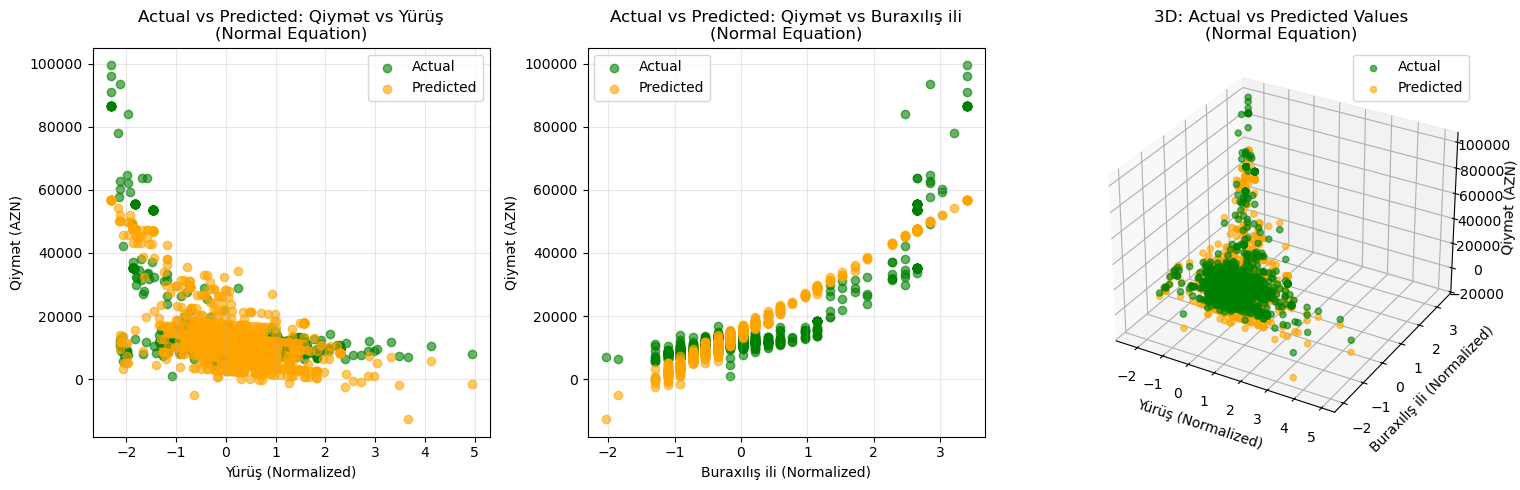

Generated 3 plots for Normal Equation method:
1. Qiymet vs Yürüş (Mileage) - Actual vs Predicted
2. Qiymet vs Buraxılış ili (Year) - Actual vs Predicted
3. 3D plot showing all three variables


In [44]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_normalized_part5[:, 0], y_target, alpha=0.6, label='Actual', color='green')
plt.scatter(X_normalized_part5[:, 0], predictions_normal, alpha=0.6, label='Predicted', color='orange')
plt.xlabel('Yürüş (Normalized)')
plt.ylabel('Qiymət (AZN)')
plt.title('Actual vs Predicted: Qiymət vs Yürüş\n(Normal Equation)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_normalized_part5[:, 1], y_target, alpha=0.6, label='Actual', color='green')
plt.scatter(X_normalized_part5[:, 1], predictions_normal, alpha=0.6, label='Predicted', color='orange')
plt.xlabel('Buraxılış ili (Normalized)')
plt.ylabel('Qiymət (AZN)')
plt.title('Actual vs Predicted: Qiymət vs Buraxılış ili\n(Normal Equation)')
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.subplot(1, 3, 3, projection='3d')
ax.scatter(X_normalized_part5[:, 0], X_normalized_part5[:, 1], y_target, alpha=0.6, label='Actual', color='green')
ax.scatter(X_normalized_part5[:, 0], X_normalized_part5[:, 1], predictions_normal, alpha=0.6, label='Predicted', color='orange')
ax.set_xlabel('Yürüş (Normalized)')
ax.set_ylabel('Buraxılış ili (Normalized)')
ax.set_zlabel('Qiymət (AZN)')
ax.set_title('3D: Actual vs Predicted Values\n(Normal Equation)')
ax.legend()

plt.tight_layout()
plt.show()

print("Generated 3 plots for Normal Equation method:")
print("1. Qiymet vs Yürüş (Mileage) - Actual vs Predicted")
print("2. Qiymet vs Buraxılış ili (Year) - Actual vs Predicted")
print("3. 3D plot showing all three variables")